In [10]:
import redback 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo 
import astropy.units as uu
from redback.transient_models.supernova_models import lambda_to_nu
import redback.interaction_processes as ip
import redback.sed as sed
import redback.photosphere as photosphere

import astropy.units as uu

import extinction
from extinction import ccm89, fitzpatrick99, apply, remove
from scipy.interpolate import RegularGridInterpolator
import sncosmo

In [11]:
from redback.model_library import all_models_dict

func = all_models_dict['sncosmo_models']

In [12]:
#1. Load in GRB event information: 
#check 98bw first to see if it returns with 1 
#use data from Jillian's file and constrain to B band only

AB_mag = 14.370000000000001 - 0.09 #B band correction 
#have to use two frequencies or two time points - pass in the same time point twice -- does this get the code working --YES 
target_obs_times = np.array([10.420000000074506, 10.420000000074506]) #days in observer frame 
target_redshift = 0.0085
target_frequencies = 6.86300e+14 # B band (FROM REDBACK FILTERS)
wavelength = np.array([4371.07000]) #angstroms
target_milky_way_ebv = 0.059 #from literature 

#interpolate sncosmo model 
baseline_flux = func(
    time=target_obs_times,
    redshift=target_redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    # ADD THESE TWO LINES:
    model_kwarg_names=[], # This tells redback there are no extra SN parameters to loop through
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 15  #changes ? 
)

#try to use gavin's model instead here !! 

print(baseline_flux)

[4.14881277 4.14881277] mJy


In [13]:
#2. Calculate de-reddened flux density for GRB event 
#in this case it is GRB 980425 but still need to calculate 
#pass in values defined above from Jillians data 

#to get a_v from E(B-V) 
a_v = target_milky_way_ebv * 3.1 

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)
print(f"This is the flux density of  GRB event without extinction correction: {flux_density_event:.5f}")

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 
print(f"This is the extinction corrected GRB event flux density found using fitzpatrick99: {dereddened_flux_event[0]:.5f}")

This is the flux density of  GRB event without extinction correction: 7.04693 mJy
This is the extinction corrected GRB event flux density found using fitzpatrick99: 8.79830 mJy


In [14]:
# 3. Take the ratio
flux_ratio = dereddened_flux_event / baseline_flux

print(flux_ratio[0])

#should be f_98 = 1 for 1998bw 

2.120678699823292


In [15]:
#back to using 1998bw_template from gavin try : 
def sn1998bw_template(time, redshift, amplitude, **kwargs):
    """
    A wrapper to the SN1998bw template. Only valid between 1100-11000 Angstrom and 0.01 to 90 days post explosion in rest frame

    Parameters
    ----------
    time
        time in days in observer frame (post explosion)
    redshift
        redshift
    amplitude
        amplitude scaling factor, where 1.0 is the original brightness of SN1998bw; and f_lambda is scaled by this factor
    kwargs
        Additional keyword arguments required by redback.
    frequency
        Required if output_format is 'flux_density'. frequency to calculate - Must be same length as time array or a single number).
    bands
        Required if output_format is 'magnitude' or 'flux'.
    output_format
        'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'
    cosmology
        Cosmology to use for luminosity distance calculation. Defaults to Planck18. Must be a astropy.cosmology object.
    Returns
    -------
        set by output format - 'flux_density', 'magnitude', 'spectra', 'flux', 'sncosmo_source'

    """
    import sncosmo
    model = sncosmo.Model(source='v19-1998bw')
    original_redshift = 0.0085
    cosmology = kwargs.get("cosmology", cosmo)
    original_dl = (43*uu.Mpc).to(uu.cm).value

    # From roughly matching to Galama+ or Clocchiatti+1998bw light curves
    original_peak_time = 15
    model.set(z=original_redshift, t0=original_peak_time)
    model.set_source_peakmag(14.25, band='bessellb', magsys='ab')
    tts = np.geomspace(0.01, 90, 200)
    lls = np.linspace(1620, 11000, 300)
    f_lambda = model.flux(tts, lls) #erg/s/cm^2/Angstrom.
    l_lambda = f_lambda * 4 * np.pi * original_dl**2  # erg/s/Angstrom

    # We consider this the rest frame spectrum of 1998bw. Now we can redshift it and scale it.
    time_obs = tts * (1 + redshift)
    lambda_obs = lls * (1 + redshift)
    dl_new = cosmology.luminosity_distance(redshift).cgs.value
    f_lambda_obs = l_lambda / (4 * np.pi * dl_new**2)
    f_lambda_obs = amplitude * f_lambda_obs * (1 + redshift) # accounting for bandwidth stretching
    f_lambda_obs = f_lambda_obs * uu.erg / uu.s / uu.cm ** 2 / uu.Angstrom
    if kwargs['output_format'] == 'flux_density':
        frequency = kwargs['frequency']
        # work in obs frame
        ff_array = lambda_to_nu(lambda_obs)

        # Convert flux density to mJy
        fmjy = f_lambda_obs.to(uu.mJy, equivalencies=uu.spectral_density(wav=lambda_obs * uu.Angstrom)).value
        # Create interpolator on obs frame grid
        flux_interpolator = RegularGridInterpolator(
            (time_obs, ff_array),
            fmjy,
            bounds_error=False,
            fill_value=0.0)

        # Prepare points for interpolation
        if isinstance(frequency, (int, float)):
            frequency = np.ones_like(time) * frequency

        # Create points for evaluation
        points = np.column_stack((time, frequency))

        # Return interpolated flux density with (1+z) correction for observer frame
        return flux_interpolator(points)
    elif kwargs['output_format'] == 'spectra':
        return namedtuple('output', ['time', 'lambdas', 'spectra'])(time=time_obs,
                                                                    lambdas=lambda_obs,
                                                                    spectra=f_lambda_obs)
    else:
        return sed.get_correct_output_format_from_spectra(time=time, time_eval=time_obs,
                                                          spectra=f_lambda_obs, lambda_array=lambda_obs,
                                                          **kwargs)

In [18]:
#try different data at a later time 
AB_mag = 15.96 - 0.09 #B band correction 
#have to use two frequencies or two time points - pass in the same time point twice
target_obs_times = np.array([37.46000000011176, 37.46000000011176]) #days in observer frame 
target_redshift = 0.0085
target_frequencies = 6.86300e+14 # B band 
wavelength = np.array([4371.07000]) #angstroms
target_milky_way_ebv = 0.059 

#interpolate sncosmo model 
# baseline_flux = func(
#     time=target_obs_times,
#     redshift=target_redshift,
#     model_kwargs=None,
#     sncosmo_model='v19-1998bw-corr',
#     output_format='flux_density', # Returns mJy
#     frequency=target_frequencies,
#     mw_extinction=True,           # Add MW dust for YOUR target
#     ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
#     # ADD THESE TWO LINES:
#     model_kwarg_names=[], # This tells redback there are no extra SN parameters to loop through
#     use_set_peak_magnitude = True,
#     peak_abs_mag = -18.6,
#     peak_time = 15  #changes ? 
# )

#try with new funcrtion modified by gavin: 

all_models_dict['sn1998bw_template'] = sn1998bw_template

func1 = all_models_dict['sn1998bw_template']

#specify a time !! 
time = np.array(37.46000000011176)

sn_1998bw1= func1(time=time,
                 redshift=0.0085,
                 model_kwargs=None,
                 amplitude = 1,
                 output_format='flux_density', # Returns mJy
                 frequency=target_frequencies,
                 mw_extinction=True,
                 # Add MW dust for YOUR target
                 ebv_mw=target_milky_way_ebv, # Specific to your GRB location
                 model_kwarg_names=[],
                 use_set_peak_magnitude = True,
                 peak_abs_mag = -18.6, #-18.88 B band ? 
                 peak_time = 16 #shifts pak time to where it actually is
                 )


#to get a_v from E(B-V) 
a_v = target_milky_way_ebv * 3.1 

#convert AB magnitude of arbitrary GRB event --> flux density (mJy)
def calc_flux_density_from_ABmag(AB_mag):
    """
    Calculate flux density from AB magnitude assuming monochromatic AB filter

    :param magnitudes: AB magnitude values
    :return: flux density
    """
    return (AB_mag * uu.ABmag).to(uu.mJy)

flux_density_event = calc_flux_density_from_ABmag(AB_mag)

#de-redden flux density, account for extinction if necessary 
dereddened_flux_event = extinction.remove(fitzpatrick99(wavelength, a_v, 3.1),flux_density_event) 

flux_ratio = dereddened_flux_event / sn_1998bw1

print(flux_ratio[0])

#is code just factor of 2 out for everything ? 

#now not a factor of 2 but nt closer to 1 ? 
#now says infinite ??!! WHY ?? BECAUSE TIME WAS STILL A RANGE ! 
#yay now = 1 !! 


1.0382655623532226 mJy


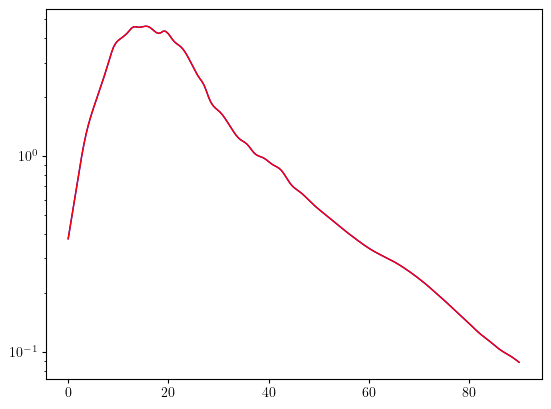

In [7]:
#plot this to see what is actually going on:
freq = target_frequencies
redshift = target_redshift
times = np.linspace(0.01,90,200)
time = target_obs_times

sn_1998bw = func(time=times,
    redshift=redshift,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    model_kwarg_names=[], 
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16 #shifts pak time to where it actually is 
)

#now use this as the SN1998bw lightcueve and the above as the GRB event with redshift defined 
sn_1998bw1= func(time=times,
    redshift=0.0085,
    model_kwargs=None,
    sncosmo_model='v19-1998bw-corr',
    output_format='flux_density', # Returns mJy
    frequency=target_frequencies,
    mw_extinction=True,           # Add MW dust for YOUR target
    ebv_mw=target_milky_way_ebv,  # Specific to your GRB location
    model_kwarg_names=[], 
    use_set_peak_magnitude = True,
    peak_abs_mag = -18.6,
    peak_time = 16 #shifts pak time to where it actually is 
)


plt.semilogy(times,sn_1998bw,'-b')
plt.semilogy(times,sn_1998bw1, '-r')

plt.show()

#on top of each other which is correct - can i plot Jillians data over this and then match it up to standardise? 